# Chapter 7 — QR factorization

**Numerical Linear Algebra: Theory, Algorithms, and Computation**

**Abdallah Alsammani, Ph.D.**  
Department of Mathematical Sciences & Data Science  
Delaware State University

Lecture notes: <https://aalsammani.github.io/numerical-linear-algebra/>  
Notes for this chapter: <https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html>  
Repository: <https://github.com/aalsammani/Numerical-Linear-Algebra-Notebooks>

This notebook is the computational laboratory of the chapter; the theory,
proofs and exercises are in the lecture notes, to which the links below
point. References such as Trefethen and Bau (1997) are listed in the
[bibliography of the notes](https://aalsammani.github.io/numerical-linear-algebra/back/bibliography.html). Version
1.0, September 2026.

---

This notebook accompanies [Chapter 7](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07) of the notes. Every
experiment checks a statement from the chapter numerically.

**Learning objectives.** After working through this lab you should be able to

1. build orthogonal projectors stably as $QQ^T$ and explain why
   $A(A^TA)^{-1}A^T$ is a poor numerical recipe;
2. implement classical Gram-Schmidt (CGS), modified Gram-Schmidt (MGS) and
   CGS with reorthogonalization (CGS2), and measure how their loss of
   orthogonality depends on $\kappa_2(A)$;
3. implement Householder QR with implicit storage of $Q$, apply $Q$ and $Q^T$
   without forming them, form $Q_1$ by backward accumulation, and verify the
   result against LAPACK;
4. compare flop counts with observed run times, and interpret the latter as
   observations on one machine;
5. use column pivoting to estimate numerical rank, and recognize when it
   fails;
6. factor an upper Hessenberg matrix with Givens rotations.

Run the cells in order from a fresh kernel.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as sla

rng = np.random.default_rng(20260707)
u = np.finfo(float).eps / 2          # unit roundoff of IEEE double precision, 2**-53
plt.rcParams.update({"figure.figsize": (6.4, 4.0), "axes.grid": True, "grid.alpha": 0.3})
print(f"NumPy {np.__version__}; unit roundoff u = {u:.3e}")


def matrix_with_condition(m, n, kappa, rng):
    """Return A = U diag(s) V^T with random orthonormal U, V and log-spaced s from 1 to 1/kappa."""
    U, _ = np.linalg.qr(rng.standard_normal((m, n)))
    V, _ = np.linalg.qr(rng.standard_normal((n, n)))
    s = np.logspace(0, -np.log10(kappa), n)
    return (U * s) @ V.T


def normalize_signs(Q, R):
    """Return (Q D, D R) with D = diag(sign(r_jj)), sign(0) = 1, so that diag(R) >= 0."""
    d = np.where(np.diag(R) < 0, -1.0, 1.0)
    return Q * d, d[:, None] * R


def orth_loss(Q):
    """||I - Q^T Q||_2, the departure of the columns of Q from orthonormality."""
    return np.linalg.norm(np.eye(Q.shape[1]) - Q.T @ Q, 2)

NumPy 2.5.3; unit roundoff u = 1.110e-16


## 1. Projectors

For $Q$ with orthonormal columns, $P = QQ^T$ is the orthogonal projector onto
$\operatorname{range}(Q)$ ([Theorem 7.3](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-thm-qqt)). For a basis $A$ that is
not orthonormal, $P = A(A^TA)^{-1}A^T$ is the same matrix in exact arithmetic
([Proposition 7.1](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-prop-projector-basis)). We build both for matrices of
increasing condition number and check the defining properties $P^2 = P$ and
$P^T = P$. We use the $Q$ factor from `numpy.linalg.qr` (Householder QR),
whose departure from orthonormality is a small multiple of $u$.

In [2]:
m, n = 100, 10
print(" kappa     ||P^2-P|| (normal eq.)  ||P-P^T|| (normal eq.)   ||P^2-P|| (QQ^T)   u*kappa^2")
for kappa in [1e0, 1e2, 1e4, 1e6, 1e8]:
    A = matrix_with_condition(m, n, kappa, rng)
    P_normal = A @ np.linalg.solve(A.T @ A, A.T)      # the formula, used literally
    Q, _ = np.linalg.qr(A)
    P_qr = Q @ Q.T
    idem_n = np.linalg.norm(P_normal @ P_normal - P_normal, 2)
    sym_n = np.linalg.norm(P_normal - P_normal.T, 2)
    idem_q = np.linalg.norm(P_qr @ P_qr - P_qr, 2)
    print(f"{kappa:7.0e}   {idem_n:20.1e}   {sym_n:20.1e}   {idem_q:16.1e}   {u * kappa**2:9.1e}")
    # QQ^T: ||P^2 - P|| = ||Q (Q^T Q - I) Q^T|| <= (1 + ||E||)||E|| with E = Q^T Q - I = O(m n u) (Householder).
    assert idem_q < 10 * m * n * u

 kappa     ||P^2-P|| (normal eq.)  ||P-P^T|| (normal eq.)   ||P^2-P|| (QQ^T)   u*kappa^2
  1e+00                3.1e-16                1.5e-16            5.4e-16     1.1e-16
  1e+02                4.0e-13                5.5e-14            4.9e-16     1.1e-12
  1e+04                8.1e-09                6.8e-10            6.3e-16     1.1e-08
  1e+06                4.2e-05                6.8e-07            4.2e-16     1.1e-04
  1e+08                3.3e-02                1.0e-02            6.0e-16     1.1e+00


**Interpretation.** $QQ^T$ is idempotent to within a few multiples of $u$
for every $\kappa$, and symmetric to rounding error. The literal formula loses idempotency and symmetry
roughly in proportion to $u\kappa_2(A)^2$, the condition number of the Gram
matrix $A^TA$. At $\kappa = 10^8$ it is no longer a projector in any useful
sense, although the columns of $A$ are linearly independent and
$Q_1Q_1^T$ is computed from the same matrix without difficulty.

An oblique projector can have a large norm. The matrix
$\begin{bmatrix}1&t\\0&0\end{bmatrix}$ is a projector for every $t$, with
$\|P\|_2 = \sqrt{1+t^2}$ ([Exercise 7.2](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-ex-projector-norms)).

In [3]:
for t in [0.0, 1.0, 10.0, 1e3]:
    P = np.array([[1.0, t], [0.0, 0.0]])
    print(f"t = {t:6g}: ||P^2 - P|| = {np.linalg.norm(P @ P - P):.0e}, ||P||_2 = {np.linalg.norm(P, 2):9.3f}, "
          f"sqrt(1+t^2) = {np.sqrt(1 + t**2):9.3f}")
    assert np.array_equal(P @ P, P)
    assert abs(np.linalg.norm(P, 2) - np.sqrt(1 + t**2)) <= 4 * u * np.sqrt(1 + t**2)   # SVD: relative error O(u)

t =      0: ||P^2 - P|| = 0e+00, ||P||_2 =     1.000, sqrt(1+t^2) =     1.000
t =      1: ||P^2 - P|| = 0e+00, ||P||_2 =     1.414, sqrt(1+t^2) =     1.414
t =     10: ||P^2 - P|| = 0e+00, ||P||_2 =    10.050, sqrt(1+t^2) =    10.050
t =   1000: ||P^2 - P|| = 0e+00, ||P||_2 =  1000.000, sqrt(1+t^2) =  1000.000


## 2. A worked example and the signs of $R$

[Example 7.2](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-exa-gs) computes the thin QR factorization of
$A = \begin{bmatrix}3&-6\\4&-8\\0&1\end{bmatrix}$ by hand:
$Q_1 = \begin{bmatrix}0.6&0\\0.8&0\\0&1\end{bmatrix}$ and
$R_1 = \begin{bmatrix}5&-10\\0&1\end{bmatrix}$. NumPy calls LAPACK, which
uses Householder reflectors with $\alpha = -\operatorname{sign}(x_1)\|x\|_2$
and does **not** make the diagonal of $R$ positive.

In [4]:
A = np.array([[3.0, -6.0], [4.0, -8.0], [0.0, 1.0]])
Q, R = np.linalg.qr(A)
print("numpy R =\n", R)
print("diag(R) =", np.diag(R), "  <- negative entries are normal: LAPACK does not normalize signs")
Qn, Rn = normalize_signs(Q, R)
print("after normalization: R =\n", Rn)
Q_hand = np.array([[0.6, 0.0], [0.8, 0.0], [0.0, 1.0]])
R_hand = np.array([[5.0, -10.0], [0.0, 1.0]])
# Small integer data: the factors agree to a few ulps of their entries (sizes <= 10).
assert np.allclose(Qn, Q_hand, rtol=0, atol=10 * u) and np.allclose(Rn, R_hand, rtol=0, atol=100 * u)
assert np.allclose(R, -R_hand, rtol=0, atol=100 * u)   # here D = diag(-1, -1), as in the Householder example of the notes

numpy R =
 [[-5. 10.]
 [ 0. -1.]]
diag(R) = [-5. -1.]   <- negative entries are normal: LAPACK does not normalize signs
after normalization: R =
 [[  5. -10.]
 [ -0.   1.]]


The uniqueness theorem ([Theorem 7.5](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-thm-qr-unique)) applies only after the
signs are normalized. Comparing unnormalized factors from two different
routines is a common source of false alarms.

## 3. Gram-Schmidt: CGS, MGS and CGS2

We implement [Algorithm 7.1](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-alg-cgs), [Algorithm 7.2](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-alg-mgs) and
[Algorithm 7.3](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-alg-cgs2). CGS computes all coefficients of column $j$ from the
original $a_j$ in one matrix-vector product; MGS updates the working vector
after each projection; CGS2 performs the CGS step twice.

In [5]:
def cgs(A):
    """Classical Gram-Schmidt: r_{1:j-1,j} = Q_{j-1}^T a_j with the original column."""
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    for j in range(n):
        R[:j, j] = Q[:, :j].T @ A[:, j]
        v = A[:, j] - Q[:, :j] @ R[:j, j]
        R[j, j] = np.linalg.norm(v)
        Q[:, j] = v / R[j, j]
    return Q, R


def mgs(A):
    """Modified Gram-Schmidt: each r_ij is computed from the partially reduced vector."""
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    for j in range(n):
        v = A[:, j].copy()
        for i in range(j):
            R[i, j] = Q[:, i] @ v
            v -= R[i, j] * Q[:, i]
        R[j, j] = np.linalg.norm(v)
        Q[:, j] = v / R[j, j]
    return Q, R


def cgs2(A):
    """CGS with one reorthogonalization of every column ("twice is enough")."""
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    for j in range(n):
        v = A[:, j].copy()
        for _ in range(2):
            s = Q[:, :j].T @ v
            v -= Q[:, :j] @ s
            R[:j, j] += s
        R[j, j] = np.linalg.norm(v)
        Q[:, j] = v / R[j, j]
    return Q, R

**Verification on a well-conditioned matrix.** For a Gaussian $60\times15$
matrix, $\kappa_2(A)$ is small (we print it), so all three methods should give
orthonormal columns to within a modest multiple of $u\kappa^2$ (the weakest of
the bounds in [Theorem 7.6](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-thm-gs-orthogonality)) and residuals of order
$u$ ([Proposition 7.4](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-prop-gs-residual)). After sign normalization they should
agree with NumPy to within a multiple of $\kappa u$ (forward error of order
condition number times backward error).

In [6]:
m, n = 60, 15
A = rng.standard_normal((m, n))
kappa = np.linalg.cond(A)
Q_ref, R_ref = normalize_signs(*np.linalg.qr(A))
print(f"kappa_2(A) = {kappa:.2f}")
for f in (cgs, mgs, cgs2):
    Q, R = f(A)
    res = np.linalg.norm(A - Q @ R, 2) / np.linalg.norm(A, 2)
    diffQ = np.linalg.norm(Q - Q_ref, 2)
    print(f"{f.__name__:5s} ||I - Q^T Q|| = {orth_loss(Q):.1e}, ||A - QR||/||A|| = {res:.1e}, ||Q - Q_numpy|| = {diffQ:.1e}")
    assert np.all(np.diag(R) > 0)                    # Gram-Schmidt produces the positive-diagonal factorization
    assert orth_loss(Q) < 10 * m * n * u * kappa**2  # CGS bound with modest constants; MGS and CGS2 are better
    assert res < 10 * m * n * u                      # small residual for all variants
    assert diffQ < 10 * m * n * u * kappa**2

kappa_2(A) = 3.11
cgs   ||I - Q^T Q|| = 5.2e-16, ||A - QR||/||A|| = 1.1e-16, ||Q - Q_numpy|| = 6.0e-16
mgs   ||I - Q^T Q|| = 7.5e-16, ||A - QR||/||A|| = 1.8e-16, ||Q - Q_numpy|| = 6.2e-16
cgs2  ||I - Q^T Q|| = 5.8e-16, ||A - QR||/||A|| = 1.1e-16, ||Q - Q_numpy|| = 5.8e-16


**Läuchli's matrix.** [Example 7.3](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-exa-lauchli) predicts, by a hand
computation in floating-point arithmetic, that CGS returns
$\widehat q_2^T\widehat q_3 = 1/2$, while MGS returns inner products of size
$\varepsilon/\sqrt2$ and $\varepsilon/\sqrt6$, and that CGS2 repairs CGS.

In [7]:
eps_l = 1e-8
A_l = np.array([[1, 1, 1], [eps_l, 0, 0], [0, eps_l, 0], [0, 0, eps_l]])
print(f"kappa_2 = {np.linalg.cond(A_l):.3e}; u*kappa = {u * np.linalg.cond(A_l):.1e}")
for f in (cgs, mgs, cgs2):
    Q, R = f(A_l)
    G = Q.T @ Q
    res = np.linalg.norm(A_l - Q @ R) / np.linalg.norm(A_l)
    print(f"{f.__name__:5s} q1.q2 = {G[0, 1]:+.2e}  q1.q3 = {G[0, 2]:+.2e}  q2.q3 = {G[1, 2]:+.2e}  residual = {res:.1e}")
Qc, _ = cgs(A_l)
Qm, _ = mgs(A_l)
assert abs(Qc[:, 1] @ Qc[:, 2] - 0.5) < 10 * u                           # the hand computation
assert abs(Qm[:, 0] @ Qm[:, 2] + eps_l / np.sqrt(6)) < 1e-3 * eps_l
assert orth_loss(cgs2(A_l)[0]) < 10 * u

kappa_2 = 1.732e+08; u*kappa = 1.9e-08
cgs   q1.q2 = -7.07e-09  q1.q3 = -7.07e-09  q2.q3 = +5.00e-01  residual = 8.3e-26
mgs   q1.q2 = -7.07e-09  q1.q3 = -4.08e-09  q2.q3 = +1.03e-16  residual = 1.4e-25
cgs2  q1.q2 = +1.18e-24  q1.q3 = +7.60e-25  q2.q3 = -3.71e-17  residual = 5.6e-25


## 4. Householder QR from scratch

We implement [Algorithm 7.4](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-alg-householder-qr) in the storage format used
by LAPACK: $R$ in the upper triangle, the Householder vectors (with implicit
leading entry $1$) below the diagonal, and the scalars $\beta_k$ in a
separate array. The Householder vector follows
[Algorithm 1.1](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01-alg-householder) with $\operatorname{sign}(0) = 1$.

In [8]:
def householder_qr(A):
    """Householder QR in factored form. Returns (F, beta): R = triu(F), v_k = [1; F[k+1:, k]]."""
    F = np.array(A, dtype=float)
    m, n = F.shape
    beta = np.zeros(n)
    for k in range(n):
        x = F[k:, k]
        normx = np.linalg.norm(x)
        if normx == 0.0:
            continue                                   # H_k = I, beta_k = 0
        s = 1.0 if x[0] >= 0 else -1.0                 # sign(0) = +1
        alpha = -s * normx
        v = x.copy()
        v[0] = x[0] - alpha                            # = x[0] + s*||x||: no cancellation
        v /= v[0]
        beta[k] = 2.0 / (v @ v)
        w = v @ F[k:, k + 1:]                          # w^T = v^T A(k:m, k+1:n): 2pq flops
        F[k:, k + 1:] -= beta[k] * np.outer(v, w)      # rank-one update: 2pq flops
        F[k, k] = alpha
        F[k + 1:, k] = v[1:]                           # store the essential part of v
    return F, beta


def apply_Qt(F, beta, B):
    """Return Q^T B = H_n ... H_1 B without forming Q (about 4mn - 2n^2 flops per column of B)."""
    B = np.array(B, dtype=float)
    n = F.shape[1]
    for k in range(n):
        v = np.concatenate(([1.0], F[k + 1:, k]))
        B[k:] -= beta[k] * np.outer(v, v @ B[k:]) if B.ndim == 2 else beta[k] * v * (v @ B[k:])
    return B


def apply_Q(F, beta, X):
    """Return Q X = H_1 ... H_n X without forming Q."""
    X = np.array(X, dtype=float)
    n = F.shape[1]
    for k in reversed(range(n)):
        v = np.concatenate(([1.0], F[k + 1:, k]))
        X[k:] -= beta[k] * np.outer(v, v @ X[k:]) if X.ndim == 2 else beta[k] * v * (v @ X[k:])
    return X


def form_Q1(F, beta):
    """Form the thin factor Q_1 = H_1 ... H_n [I_n; 0] by backward accumulation."""
    m, n = F.shape
    Q = np.zeros((m, n))
    Q[:n, :n] = np.eye(n)
    for k in reversed(range(n)):
        v = np.concatenate(([1.0], F[k + 1:, k]))
        Q[k:, k:] -= beta[k] * np.outer(v, v @ Q[k:, k:])   # only rows k:m, columns k:n are touched
    return Q

**Verification against LAPACK.** `scipy.linalg.qr(A, mode="raw")` returns the
output of LAPACK's `geqrf`, which uses the same sign convention and the same
normalization $v_1 = 1$. Our factored form should agree with it to rounding
error, which for this well-conditioned matrix means a modest multiple of
$u\|A\|$.

In [9]:
m, n = 9, 5
A = rng.standard_normal((m, n))
F, beta = householder_qr(A)
(F_lapack, tau), _ = sla.qr(A, mode="raw")
print("max |F - F_lapack|  =", np.max(np.abs(F - F_lapack)))
print("max |beta - tau|    =", np.max(np.abs(beta - tau)))
assert np.max(np.abs(F - F_lapack)) < 100 * m * n * u * np.linalg.norm(A, 2)
assert np.max(np.abs(beta - tau)) < 100 * m * u   # beta = 2/(v^T v) in [1, 2]

max |F - F_lapack|  = 1.3322676295501878e-15
max |beta - tau|    = 2.220446049250313e-16


Now the thin factors, the implicit products, and a comparison with
`numpy.linalg.qr` after sign normalization. The tolerances come from
[Theorem 7.7](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-thm-householder-stability): residual and loss of
orthogonality are $O(mn^{3/2}u)$, with no dependence on $\kappa$.

In [10]:
m, n = 300, 80
A = rng.standard_normal((m, n))
F, beta = householder_qr(A)
R1 = np.triu(F[:n])
Q1 = form_Q1(F, beta)
res = np.linalg.norm(A - Q1 @ R1, "fro") / np.linalg.norm(A, "fro")
print(f"||A - Q1 R1||_F/||A||_F = {res:.1e},  ||I - Q1^T Q1||_2 = {orth_loss(Q1):.1e},  m n^1.5 u = {m * n**1.5 * u:.1e}")
assert res < m * n**1.5 * u and orth_loss(Q1) < m * n**1.5 * u

Qn, Rn = normalize_signs(*np.linalg.qr(A))
Qm, Rm = normalize_signs(Q1, R1)
kappa = np.linalg.cond(A)
print(f"kappa = {kappa:.2f}; after sign normalization ||Q1 - Q_numpy|| = {np.linalg.norm(Qm - Qn, 2):.1e}, "
      f"||R1 - R_numpy||/||R|| = {np.linalg.norm(Rm - Rn, 2) / np.linalg.norm(Rn, 2):.1e}")
assert np.linalg.norm(Qm - Qn, 2) < kappa * m * n**1.5 * u   # forward difference ~ condition x backward error

b = rng.standard_normal(m)
x = rng.standard_normal(n)
Qtb = apply_Qt(F, beta, b)
print(f"||Q^T b (implicit) - Q1^T b|| = {np.linalg.norm(Qtb[:n] - Q1.T @ b):.1e};  "
      f"norm preserved: | ||Q^T b|| - ||b|| | / ||b|| = {abs(np.linalg.norm(Qtb) - np.linalg.norm(b)) / np.linalg.norm(b):.1e}")
assert np.linalg.norm(Qtb[:n] - Q1.T @ b) < m * n**1.5 * u * np.linalg.norm(b)
x_pad = np.concatenate([x, np.zeros(m - n)])
assert np.linalg.norm(apply_Q(F, beta, x_pad) - Q1 @ x) < m * n**1.5 * u * np.linalg.norm(x)
assert np.linalg.norm(apply_Q(F, beta, apply_Qt(F, beta, b)) - b) < m * n**1.5 * u * np.linalg.norm(b)

||A - Q1 R1||_F/||A||_F = 6.4e-16,  ||I - Q1^T Q1||_2 = 1.4e-15,  m n^1.5 u = 2.4e-11
kappa = 3.02; after sign normalization ||Q1 - Q_numpy|| = 1.6e-15, ||R1 - R_numpy||/||R|| = 5.4e-16
||Q^T b (implicit) - Q1^T b|| = 6.6e-15;  norm preserved: | ||Q^T b|| - ||b|| | / ||b|| = 0.0e+00


The implicit application of $Q^T$ is exactly what a least-squares solver
needs ([Chapter 8](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08)): $Q^Tb$ in about $4mn$ flops, without ever
forming the $m\times m$ matrix $Q$.

## 5. Loss of orthogonality versus $\kappa$

This reproduces [Figure 7.2](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-fig-orthogonality) with our own
implementations, including our Householder QR. For each $\kappa$ we build a
$50\times20$ matrix with singular values logarithmically spaced between $1$
and $1/\kappa$, and measure $\|I - \widehat Q^T\widehat Q\|_2$ and the
residual $\|A - \widehat Q\widehat R\|_2/\|A\|_2$.

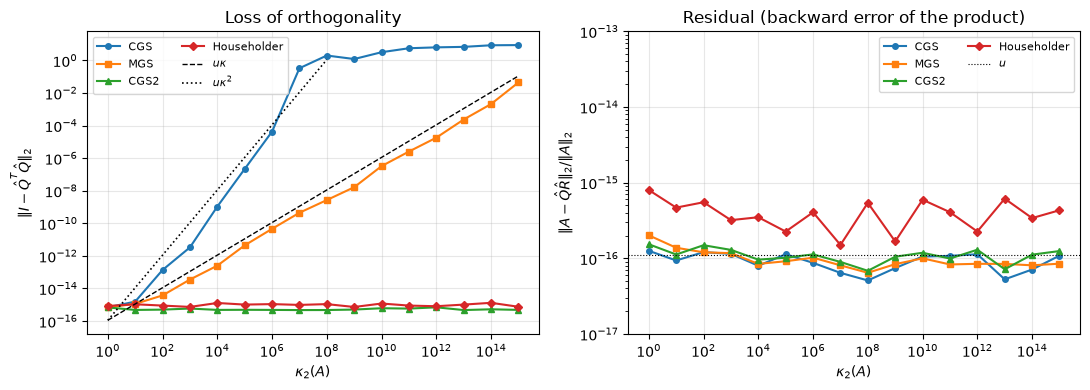

kappa    CGS        MGS        CGS2       Householder
1e8      2.0e+00    2.7e-09    4.7e-16    1.1e-15
1e12     6.3e+00    1.8e-05    6.9e-16    8.1e-16


In [11]:
def householder_thin(A):
    F, beta = householder_qr(A)
    n = A.shape[1]
    return form_Q1(F, beta), np.triu(F[:n])


methods = {"CGS": cgs, "MGS": mgs, "CGS2": cgs2, "Householder": householder_thin}
kappas = 10.0 ** np.arange(0, 16)
m, n = 50, 20
loss = {name: [] for name in methods}
resid = {name: [] for name in methods}
for kappa in kappas:
    A = matrix_with_condition(m, n, kappa, rng)
    for name, f in methods.items():
        Q, R = f(A)
        loss[name].append(orth_loss(Q))
        resid[name].append(np.linalg.norm(A - Q @ R, 2) / np.linalg.norm(A, 2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, marker in zip(methods, "os^D"):
    axes[0].loglog(kappas, loss[name], marker=marker, ms=4, label=name)
    axes[1].loglog(kappas, resid[name], marker=marker, ms=4, label=name)
axes[0].loglog(kappas, u * kappas, "k--", lw=1, label=r"$u\kappa$")
k2 = kappas[u * kappas**2 < 10]
axes[0].loglog(k2, u * k2**2, "k:", lw=1.2, label=r"$u\kappa^2$")
axes[0].set_ylabel(r"$\|I - \hat Q^T\hat Q\|_2$")
axes[0].set_title("Loss of orthogonality")
axes[1].axhline(u, color="k", lw=0.8, ls=":", label="$u$")
axes[1].set_ylabel(r"$\|A - \hat Q\hat R\|_2 / \|A\|_2$")
axes[1].set_title("Residual (backward error of the product)")
axes[1].set_ylim(1e-17, 1e-13)
for ax in axes:
    ax.set_xlabel(r"$\kappa_2(A)$")
    ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print("kappa    CGS        MGS        CGS2       Householder")
for i in (8, 12):
    print(f"1e{i:<3d}  " + "  ".join(f"{loss[name][i]:9.1e}" for name in methods))

loss = {k: np.array(v) for k, v in loss.items()}
# ch07-thm-gs-orthogonality and ch07-thm-householder-stability: MGS ~ u kappa; CGS2, Householder O(u).
assert np.all(loss["MGS"] < 100 * u * kappas)
assert np.all(loss["CGS2"] < 100 * u) and np.all(loss["Householder"] < m * n**1.5 * u)
assert loss["CGS"][kappas == 1e10][0] > 1e-2                    # CGS has lost orthogonality by kappa = 1e10
assert max(max(r) for r in resid.values()) < 10 * m * n * u     # all residuals are small

**Interpretation.** The curves have the slopes predicted by
[Theorem 7.6](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-thm-gs-orthogonality): slope 1 for MGS (parallel to
$u\kappa$) and slope 2 for CGS (parallel to $u\kappa^2$) until it saturates
at order one near $\kappa\approx u^{-1/2}\approx10^8$. The hypotheses of the
theorem ($u\kappa$ or $u\kappa^2$ sufficiently small) fail at the right end of
the plot, yet MGS continues roughly along $u\kappa$ and CGS2 stays near $u$:
these are observations, not guarantees. The right panel shows that all four
methods produce factors whose product reproduces $A$ to working accuracy.
The difference between them is entirely in the orthogonality of
$\widehat Q$, which the residual cannot detect.

The exact values printed above depend on the random matrices and on the
machine; the notes quote the values from the figure script, which uses a
fixed seed and NumPy's Householder QR.

## 6. Cost: flops versus observed time

[Proposition 7.5](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-prop-householder-cost) predicts $2mn^2 - \tfrac23n^3$ flops.
We time LAPACK's Householder QR (`numpy.linalg.qr(A, mode="r")`, which does not
form $Q$) and our Python implementation, taking the median of several runs.
The ratio of predicted flops to time is an observed rate on the machine that
ran this notebook.

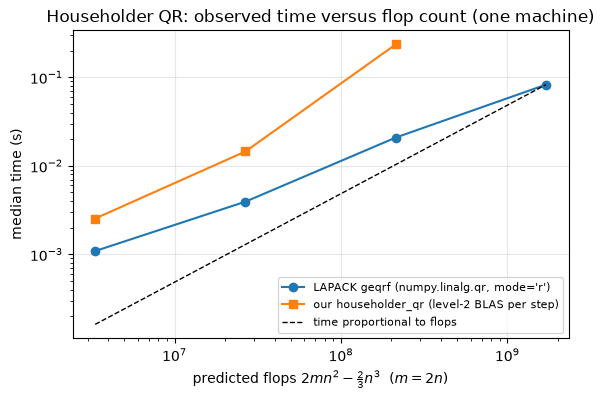

m x n =   200 x  100: LAPACK     1.09 ms, observed rate    3.1 Gflop/s
m x n =   400 x  200: LAPACK     3.93 ms, observed rate    6.8 Gflop/s
m x n =   800 x  400: LAPACK    20.86 ms, observed rate   10.2 Gflop/s
m x n =  1600 x  800: LAPACK    82.65 ms, observed rate   20.6 Gflop/s
m x n =   200 x  100: ours       2.54 ms, observed rate    1.3 Gflop/s
m x n =   400 x  200: ours      14.52 ms, observed rate    1.8 Gflop/s
m x n =   800 x  400: ours     235.49 ms, observed rate    0.9 Gflop/s


In [12]:
def median_time(f, *args, repeats=5):
    f(*args)                                   # warm-up
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        f(*args)
        times.append(time.perf_counter() - t0)
    return float(np.median(times))


def flops_qr(m, n):
    return 2 * m * n**2 - 2 * n**3 / 3


shapes = [(2 * n, n) for n in (100, 200, 400, 800)]
t_lapack = [median_time(lambda A: np.linalg.qr(A, mode="r"), rng.standard_normal(s)) for s in shapes]
t_ours = [median_time(householder_qr, rng.standard_normal(s), repeats=3) for s in shapes[:3]]
fl = np.array([flops_qr(*s) for s in shapes])

fig, ax = plt.subplots()
ax.loglog(fl, t_lapack, "o-", label="LAPACK geqrf (numpy.linalg.qr, mode='r')")
ax.loglog(fl[:3], t_ours, "s-", label="our householder_qr (level-2 BLAS per step)")
ax.loglog(fl, t_lapack[-1] * fl / fl[-1], "k--", lw=1, label="time proportional to flops")
ax.set_xlabel(r"predicted flops $2mn^2 - \frac{2}{3}n^3$  ($m = 2n$)")
ax.set_ylabel("median time (s)")
ax.set_title("Householder QR: observed time versus flop count (one machine)")
ax.legend(fontsize=8)
plt.show()
for s, f_, t in zip(shapes, fl, t_lapack):
    print(f"m x n = {s[0]:5d} x {s[1]:4d}: LAPACK {t * 1e3:8.2f} ms, observed rate {f_ / t / 1e9:6.1f} Gflop/s")
for s, f_, t in zip(shapes, fl, t_ours):
    print(f"m x n = {s[0]:5d} x {s[1]:4d}: ours   {t * 1e3:8.2f} ms, observed rate {f_ / t / 1e9:6.1f} Gflop/s")

**Interpretation.** The flop count is the machine-independent prediction:
for large sizes, time should grow roughly in proportion to it, that is, by a
factor of about $8$ each time $m$ and $n$ are doubled. For small sizes fixed
overheads dominate. LAPACK is normally much faster than our implementation,
although both perform the same flops, because `geqrf` applies blocks of
reflectors with matrix-matrix products (compact WY form) while our loop
applies one reflector at a time with matrix-vector operations and pays the
Python interpreter's overhead at every step. On a busy machine the timings
can be erratic, which is one reason to report medians and to treat all of
these numbers as observations on one machine and BLAS library, not as
properties of the algorithm.

## 7. Column pivoting and numerical rank

We construct a $60\times40$ matrix of rank $10$ whose first five columns are
all multiples of one vector, add noise of size $10^{-10}$, and compare the
diagonal of $R$ with and without pivoting. `scipy.linalg.qr(A, pivoting=True)`
returns an index vector `p` with `A[:, p] = Q @ R`.

numerical rank from pivoted QR (tolerance 4.0e-05): 10
number of unpivoted |r_kk| above the same tolerance: 10, first small one at k = 2
singular values 9..12: [2.25e+01 1.16e+01 1.18e-09 1.10e-09]


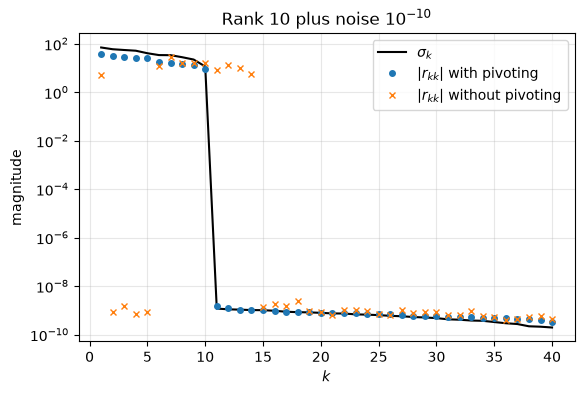

In [13]:
m, n, r = 60, 40, 10
x = rng.standard_normal((m, 1))
A = np.hstack([x @ rng.standard_normal((1, 5)),
               rng.standard_normal((m, r - 1)) @ rng.standard_normal((r - 1, n - 5))])
A += 1e-10 * rng.standard_normal((m, n))
Q, R, p = sla.qr(A, pivoting=True)
R0 = np.linalg.qr(A, mode="r")
sigma = np.linalg.svd(A, compute_uv=False)

tol = 1e-6 * abs(R[0, 0])
rank_qrcp = int(np.sum(np.abs(np.diag(R)) > tol))
print(f"numerical rank from pivoted QR (tolerance {tol:.1e}): {rank_qrcp}")
print(f"number of unpivoted |r_kk| above the same tolerance: {int(np.sum(np.abs(np.diag(R0)) > tol))}, "
      f"first small one at k = {int(np.argmax(np.abs(np.diag(R0)) < tol)) + 1}")
print("singular values 9..12:", np.array2string(sigma[8:12], precision=2))
assert np.allclose(A[:, p], Q @ R, atol=100 * m * n * u * np.linalg.norm(A, 2))
assert rank_qrcp == r
assert np.all(np.diff(np.abs(np.diag(R))) <= 1e-12 * abs(R[0, 0]))   # |r_kk| nonincreasing (ch07-thm-qrcp)
R22 = R[r:, r:]
assert sigma[r] <= np.linalg.norm(R22, 2) * (1 + 1e-8)               # sigma_{k+1} <= ||R22||_2

fig, ax = plt.subplots()
k = np.arange(1, n + 1)
ax.semilogy(k, sigma, "k-", label=r"$\sigma_k$")
ax.semilogy(k, np.abs(np.diag(R)), "o", ms=4, label=r"$|r_{kk}|$ with pivoting")
ax.semilogy(k, np.abs(np.diag(R0)), "x", ms=5, label=r"$|r_{kk}|$ without pivoting")
ax.set_xlabel("$k$")
ax.set_ylabel("magnitude")
ax.set_title("Rank 10 plus noise $10^{-10}$")
ax.legend()
plt.show()

With pivoting, the first ten $|r_{kk}|$ track $\sigma_1,\dots,\sigma_{10}$ and
the remaining ones sit at the noise level, as
[Theorem 7.8](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-thm-qrcp) suggests. Without pivoting, small diagonal entries
appear at positions $2$ to $5$ (the parallel columns) and large ones after
them, so "the first small $r_{kk}$" would suggest rank one.

**The Kahan matrix.** Column pivoting can fail. For
$K_{50}(\theta)$ with $\theta = 1.2$ (with the tiny diagonal perturbation of
the notes), no interchanges occur and $|r_{nn}|$ is not small, although
$\sigma_n$ is tiny.

In [14]:
def kahan(n, theta, pert=25):
    s, c = np.sin(theta), np.cos(theta)
    K = np.diag(s ** np.arange(n)) @ (np.eye(n) - c * np.triu(np.ones((n, n)), 1))
    return K + np.diag(pert * np.finfo(float).eps * np.arange(n, 0, -1))


K = kahan(50, 1.2)
_, RK, pK = sla.qr(K, pivoting=True)
sK = np.linalg.svd(K, compute_uv=False)
print("column norms of K (min, max):", np.linalg.norm(K, axis=0).min(), np.linalg.norm(K, axis=0).max())
print("permutation is the identity:", np.array_equal(pK, np.arange(50)))
print(f"|r_nn| = {abs(RK[-1, -1]):.2e},  sigma_n = {sK[-1]:.2e},  sigma_(n-1) = {sK[-2]:.2e}")
assert abs(RK[-1, -1]) > 1e5 * sK[-1]

column norms of K (min, max): 0.9999999999999999 1.0000000000002776
permutation is the identity: True
|r_nn| = 3.18e-02,  sigma_n = 1.56e-08,  sigma_(n-1) = 3.98e-02


The diagonal of $R$ bounds the singular values only weakly:
$\sigma_n\le|r_{kk}|\le\sigma_1$ for every $k$ ([Exercise 7.10](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-ex-diag-sigma)).
When rank decisions matter, confirm them with the SVD.

## 8. Givens QR of an upper Hessenberg matrix

An upper Hessenberg matrix has one nonzero subdiagonal, so $n-1$ rotations
suffice, at a cost of about $3n^2$ flops. We use the rotation convention of
[Chapter 1](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01): $G = \begin{bmatrix}c&s\\-s&c\end{bmatrix}$ with
$c = x_i/r$, $s = x_j/r$ and $r$ computed by `hypot`.

In [15]:
def givens(a, b):
    """Return (c, s) with [[c, s], [-s, c]] @ [a, b] = [r, 0]."""
    if b == 0.0:
        return 1.0, 0.0
    r = np.hypot(a, b)
    return a / r, b / r


def hessenberg_qr(H):
    """QR of an upper Hessenberg matrix by n-1 Givens rotations. Returns R and the list of (c, s)."""
    R = np.array(H, dtype=float)
    n = R.shape[0]
    rotations = []
    for k in range(n - 1):
        c, s = givens(R[k, k], R[k + 1, k])
        G = np.array([[c, s], [-s, c]])
        R[k:k + 2, k:] = G @ R[k:k + 2, k:]      # 6(n-k) flops: only two rows change
        R[k + 1, k] = 0.0
        rotations.append((c, s))
    return R, rotations


def hessenberg_apply_Q(rotations, X):
    """Return Q X where Q^T = G_{n-1} ... G_1, i.e. Q = G_1^T ... G_{n-1}^T."""
    X = np.array(X, dtype=float)
    for k in reversed(range(len(rotations))):
        c, s = rotations[k]
        X[k:k + 2] = np.array([[c, -s], [s, c]]) @ X[k:k + 2]
    return X


n = 200
# A Hessenberg matrix orthogonally similar to a Gaussian matrix, so it has the same (modest) condition number.
H = sla.hessenberg(rng.standard_normal((n, n)))
H = np.triu(H, -1)                                  # remove rounding-level entries below the subdiagonal
R, rots = hessenberg_qr(H)
Q = hessenberg_apply_Q(rots, np.eye(n))
res = np.linalg.norm(H - Q @ R, 2) / np.linalg.norm(H, 2)
print(f"||H - QR||/||H|| = {res:.1e}, ||I - Q^T Q|| = {orth_loss(Q):.1e}, rotations used: {len(rots)}")
assert res < 10 * n * u and orth_loss(Q) < 10 * n * u     # Givens QR is backward stable: O(n u) here
assert np.allclose(np.tril(R, -1), 0)

Qs, Rs = normalize_signs(*np.linalg.qr(H))
_, Rg = normalize_signs(Q, R)
kappa = np.linalg.cond(H)
print(f"kappa(H) = {kappa:.1e}; after sign normalization ||R_givens - R_numpy||/||R|| = "
      f"{np.linalg.norm(Rg - Rs, 2) / np.linalg.norm(Rs, 2):.1e}")
assert np.linalg.norm(Rg - Rs, 2) / np.linalg.norm(Rs, 2) < 10 * kappa * n * u

RQ = R @ Q
print("R Q is upper Hessenberg:", np.allclose(np.tril(RQ, -2), 0, atol=10 * n * u * np.linalg.norm(H, 2)))

||H - QR||/||H|| = 6.1e-16, ||I - Q^T Q|| = 1.5e-15, rotations used: 199


kappa(H) = 4.9e+02; after sign normalization ||R_givens - R_numpy||/||R|| = 1.4e-15
R Q is upper Hessenberg: True


The product $RQ$ is again upper Hessenberg. One step of the QR algorithm of
[Chapter 10](https://aalsammani.github.io/numerical-linear-algebra/ch10-qr-algorithm/notes.html#ch10) replaces $H$ by $RQ = Q^THQ$, so each step on a
Hessenberg matrix costs $O(n^2)$ rather than $O(n^3)$ flops.

## 9. Tall and skinny matrices: CholeskyQR

CholeskyQR ([Remark 7.1](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-rem-tall-skinny)) computes $R$ as the Cholesky
factor of $A^TA$ and $Q = AR^{-1}$. It is fast, but it forms $A^TA$.

In [16]:
def cholesky_qr(A):
    R = np.linalg.cholesky(A.T @ A).T               # upper triangular, A^T A = R^T R
    Q = sla.solve_triangular(R, A.T, trans="T", lower=False).T   # Q = A R^{-1}
    return Q, R


m, n = 5000, 20
print(" kappa    CholeskyQR   Householder")
for kappa in [1e0, 1e2, 1e4, 1e6, 1e7, 1e8, 1e9]:
    A = matrix_with_condition(m, n, kappa, rng)
    Qh, _ = np.linalg.qr(A)
    try:
        Qc, _ = cholesky_qr(A)
        chol = f"{orth_loss(Qc):11.1e}"
    except np.linalg.LinAlgError:
        chol = "   breakdown"
    print(f"{kappa:7.0e}  {chol}   {orth_loss(Qh):11.1e}")

 kappa    CholeskyQR   Householder
  1e+00      4.7e-16       1.2e-15
  1e+02      2.9e-13       1.6e-15
  1e+04      6.6e-10       1.2e-15
  1e+06      5.3e-06       1.3e-15
  1e+07      4.9e-04       9.3e-16
  1e+08      1.4e-01       1.6e-15
  1e+09     breakdown       1.3e-15


The loss of orthogonality of CholeskyQR grows roughly like $u\kappa^2$, and
the Cholesky factorization breaks down (or produces garbage) once
$u\kappa^2$ is no longer small. Householder QR is unaffected.
[Exercise 7.12](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-ex-cholqr) asks you to add CholeskyQR2 and timings.

## Common mistakes

- Expecting a positive diagonal from `numpy.linalg.qr` or `scipy.linalg.qr`,
  or comparing factors from two routines without normalizing signs.
- Forming $A(A^TA)^{-1}A^T$ or `inv(A.T @ A)` to project or to solve
  least-squares problems.
- Forming the full $m\times m$ $Q$ (`mode="complete"` or SciPy's default
  `mode="full"`) when only $Q^Tb$ or the thin $Q_1$ is needed.
- Using CGS without reorthogonalization when the columns may be nearly
  dependent, or judging an orthogonalization only by its residual
  $\|A - QR\|$, which is small for every method.
- Using `np.sign(x[0])` in the Householder vector, which returns $0$ for
  $x_1 = 0$ and breaks the reflector; use $\operatorname{sign}(0) = 1$.
- Treating the count of large $|r_{kk}|$ from pivoted QR as a proof of
  numerical rank.

## Your turn

1. Modify `householder_qr` to use `np.sign(x[0])` and apply it to the
   matrix of [Exercise 7.6](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-ex-householder-hand), whose first entry is $0$. What
   happens, and why?
2. Add MGS with reorthogonalization (MGS2) to the experiment of Section 5.
   Is it better than CGS2? Which one would you prefer on a parallel
   computer, and why?
3. Use `apply_Qt` to solve the least-squares problem $\min\|Ax-b\|_2$ by
   solving $R_1x = (Q^Tb)_{1:n}$, and compare with `numpy.linalg.lstsq` for
   $\kappa_2(A) = 10^{10}$ ([Chapter 8](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08)).
4. Implement QR updating after appending a row ([Exercise 7.8](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07-ex-givens-update))
   and verify it against recomputing the factorization.

## Key takeaways

- Orthogonal projectors are $QQ^T$; the formula $A(A^TA)^{-1}A^T$ loses
  symmetry and idempotency at the rate $u\kappa^2$.
- All Gram-Schmidt variants have small residuals; their orthogonality
  differs: $u\kappa$ for MGS, $u\kappa^2$ for CGS (until it saturates), and
  $u$ for CGS2 and Householder QR.
- Householder QR stores $Q$ implicitly in the space of the zeros it
  creates, applies $Q^T$ in $4mn$ flops per vector, reproduces LAPACK's
  factored form, and is backward stable.
- LAPACK does not normalize the signs of $\operatorname{diag}(R)$.
- Column pivoting usually reveals numerical rank, but the Kahan matrix shows
  that it can fail.

## Further reading

Trefethen and Bau (1997), Lectures 6--10 and 16; Golub and Van Loan (2013),
Chapter 5; Higham (2002), Chapter 19; Giraud et al. (2005a) for the
loss of orthogonality in Gram-Schmidt; Demmel et al. (2012) for
communication-avoiding QR.